In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

In [3]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dash import Dash, dcc, html, Input, Output, callback
import dash_bootstrap_components as dbc

In [4]:
from scipy.stats import (
    ttest_ind, f_oneway, pearsonr,
    chi2_contingency, shapiro, mannwhitneyu,
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [6]:
states = pd.read_csv("data-oKFfw.csv")
states.head(5)

,SUMLEV,REGION,DIVISION,STATE,NAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,DOMESTICMIG2022,DOMESTICMIG2023,DOMESTICMIG2024,DOMESTICMIG2025,RATEDOMESTICMIG2021,RATEDOMESTICMIG2022,RATEDOMESTICMIG2023,RATEDOMESTICMIG2024,RATEDOMESTICMIG2025,rank
0,40,South,South Atlantic,45,South Carolina,5118250,5131992,5194346,5288957,5390798,...,83341,79536,66367,66622,13.2,15.9,14.9,12.2,12.05,1st
1,40,West,Mountain,16,Idaho,1839123,1849328,1904855,1942951,1970497,...,28019,14713,15975,19915,27.9,14.6,7.5,8.0,9.88,2nd
2,40,South,South Atlantic,37,North Carolina,10441392,10450215,10565503,10705768,10871849,...,98454,98929,83059,84064,9.9,9.3,9.2,7.6,7.56,3rd
3,40,South,South Atlantic,10,Delaware,989950,991890,1005130,1020279,1035354,...,12530,9872,8040,6855,13.7,12.4,9.6,7.7,6.50,4th
4,40,South,East South Central,47,Tennessee,6912319,6927736,6966687,7063325,7153029,...,82316,60397,46496,42389,6.7,11.7,8.5,6.5,5.82,5th


In [7]:
states['pop_growth_pct'] = (states['POPESTIMATE2025'] - states['POPESTIMATE2020']) / states['POPESTIMATE2020'] * 100
states['avg_mig_rate']   = states[['RATEDOMESTICMIG2021','RATEDOMESTICMIG2022',
                            'RATEDOMESTICMIG2023','RATEDOMESTICMIG2024',
                            'RATEDOMESTICMIG2025']].mean(axis=1)
states['total_net_mig']  = states[['DOMESTICMIG2021','DOMESTICMIG2022',
                            'DOMESTICMIG2023','DOMESTICMIG2024',
                            'DOMESTICMIG2025']].sum(axis=1)
states['mig_trend']  = states['RATEDOMESTICMIG2025'] - states['RATEDOMESTICMIG2021']

In [9]:
YEARS     = [2021, 2022, 2023, 2024, 2025]
MIG_COLS  = [f"DOMESTICMIG{y}"     for y in YEARS]
RATE_COLS = [f"RATEDOMESTICMIG{y}" for y in YEARS]
POP_COLS  = [f"POPESTIMATE{y}"     for y in [2020] + YEARS]

states["rate_volatility"]  = states[RATE_COLS].std(axis=1)                               # consistency measure
states["peak_year"]        = states[MIG_COLS].idxmax(axis=1).str[-4:].astype(int)
states["is_gainer"]        = (states["total_net_mig"] > 0).astype(int)
states["gainer_label"]     = states["is_gainer"].map({1: "Net Gainer", 0: "Net Loser"})

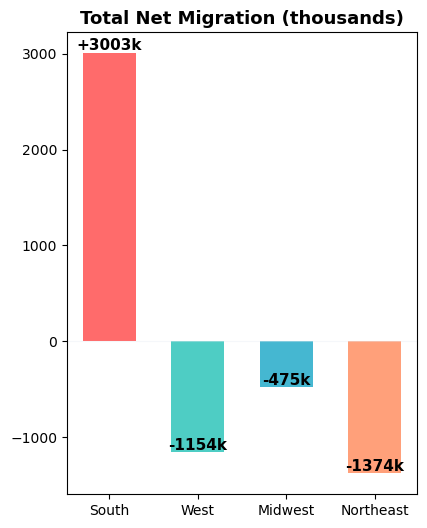

In [53]:
REGION_CLR = {
    "South":     "#FF6B6B",
    "West":      "#4ECDC4",
    "Midwest":   "#45B7D1",
    "Northeast": "#FFA07A"
}
DARK_BG  = "#0D1117"
PANEL_BG = "#161B22"
TEXT_CLR = "#E6EDF3"
GRID_CLR = "#21262D"
ACCENT   = "#58A6FF"

reg_order = ["South", "West", "Midwest", "Northeast"]
clrs      = [REGION_CLR[r] for r in reg_order]
 
fig = plt.figure(figsize=(17, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Panel A: total net migration
ax1 = fig.add_subplot(gs[0])
totals = [states[states["REGION"] == r]["total_net_mig"].sum() / 1_000 for r in reg_order]
bars = ax1.bar(reg_order, totals, color=clrs, edgecolor="none", width=0.6)
for b, v in zip(bars, totals):
    ax1.text(b.get_x() + b.get_width() / 2,
    b.get_height() + (3 if v >= 0 else -12),
    f"{v:+.0f}k", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_title("Total Net Migration (thousands)", fontsize=13, fontweight="bold")
ax1.axhline(0, color=TEXT_CLR, linewidth=0.8, alpha=0.4)


Text(0.5, 1.02, 'Regional Migration Breakdown  ·  2021–2025')

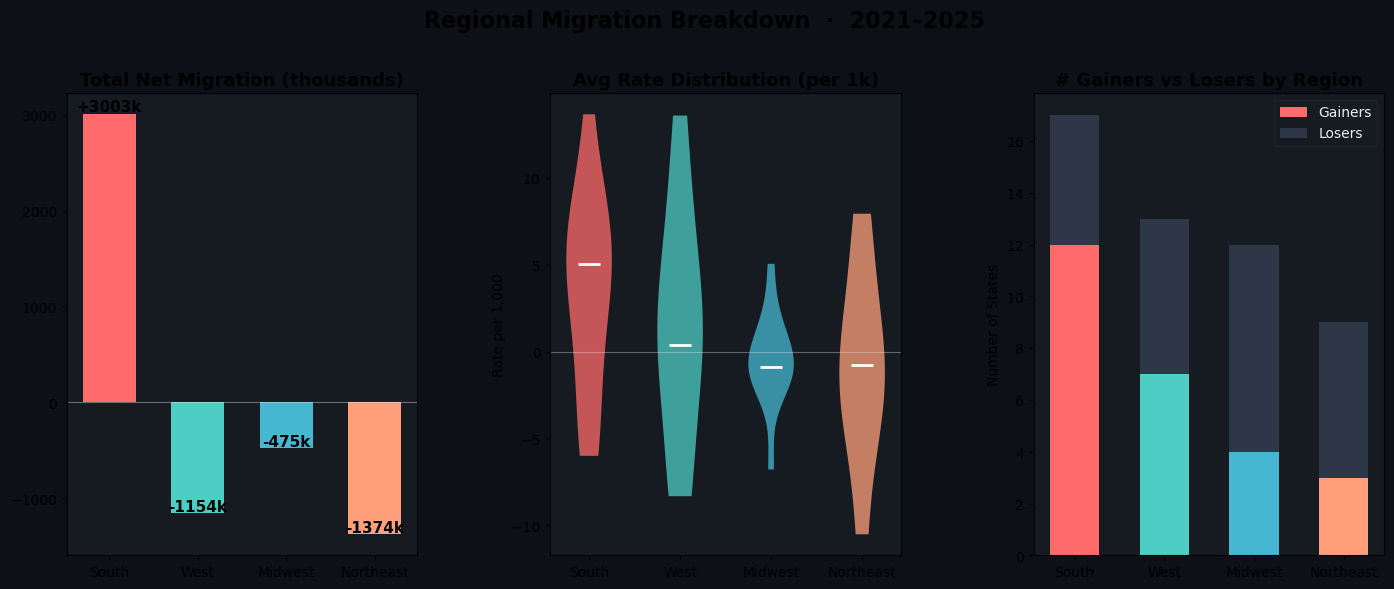

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [57]:
reg_order = ["South", "West", "Midwest", "Northeast"]
clrs      = [REGION_CLR[r] for r in reg_order]
 
fig = plt.figure(figsize=(17, 6), facecolor=DARK_BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)
 
# ── Panel A: total net migration
ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor(PANEL_BG)
totals = [df[df["REGION"] == r]["total_net_mig"].sum() / 1_000 for r in reg_order]
bars = ax1.bar(reg_order, totals, color=clrs, edgecolor="none", width=0.6)
for b, v in zip(bars, totals):
    ax1.text(b.get_x() + b.get_width() / 2,
    b.get_height() + (3 if v >= 0 else -12),
    f"{v:+.0f}k", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_title("Total Net Migration (thousands)", fontsize=13, fontweight="bold")
ax1.axhline(0, color=TEXT_CLR, linewidth=0.8, alpha=0.4)
 
# ── Panel B: average rate violin
ax2 = fig.add_subplot(gs[1]); ax2.set_facecolor(PANEL_BG)
data_v = [states[states["REGION"] == r]["avg_mig_rate"].values for r in reg_order]
vp = ax2.violinplot(data_v, showmedians=True, showextrema=False)
for pc, c in zip(vp["bodies"], clrs):
    pc.set_facecolor(c); pc.set_alpha(0.75)
vp["cmedians"].set_colors("white")
vp["cmedians"].set_linewidth(2)
ax2.set_xticks(range(1, 5)); ax2.set_xticklabels(reg_order, fontsize=10)
ax2.axhline(0, color=TEXT_CLR, linewidth=0.8, alpha=0.35)
ax2.set_title("Avg Rate Distribution (per 1k)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Rate per 1,000")
 
# ── Panel C: stacked gainer / loser count
ax3 = fig.add_subplot(gs[2]); ax3.set_facecolor(PANEL_BG)
gainers = [states[states["REGION"] == r]["is_gainer"].sum() for r in reg_order]
losers  = [len(states[states["REGION"] == r]) - g for g, r in zip(gainers, reg_order)]
ax3.bar(reg_order, gainers, color=clrs, label="Gainers", width=0.55)
ax3.bar(reg_order, losers, bottom=gainers, color="#2D3748", label="Losers", width=0.55)
ax3.set_title("# Gainers vs Losers by Region", fontsize=13, fontweight="bold")
ax3.set_ylabel("Number of States")
ax3.legend(facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
 
fig.suptitle("Regional Migration Breakdown  ·  2021–2025",fontsize=16, fontweight="bold", y=1.02)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X_c = states[['avg_mig_rate','pop_growth_pct','mig_trend','RATEDOMESTICMIG2025','RATEDOMESTICMIG2021']].fillna(0)
sc  = StandardScaler()
km  = KMeans(n_clusters=4, random_state=42, n_init=10)
states['cluster'] = km.fit_predict(sc.fit_transform(X_c))
CLUSTER_MAP = {0:'Migration Magnet', 1:'Declining Hub', 2:'Stable State', 3:'Emerging Gainer'}
# Remap by mean rate descending
order = states.groupby('cluster')['RATEDOMESTICMIG2025'].mean().sort_values(ascending=False).index.tolist()
remap = {old: ['Migration Magnet','Emerging Gainer','Stable State','Declining Hub'][i]
         for i, old in enumerate(order)}
states['cluster_label'] = states['cluster'].map(remap)

In [27]:
hyp_results = []
south_r = states[states['REGION']=='South']['RATEDOMESTICMIG2025']
non_r   = states[states['REGION']!='South']['RATEDOMESTICMIG2025']
t1, p1  = stats.ttest_ind(south_r, non_r, alternative='greater')
hyp_results.append({'Hypothesis':'H1: South > Non-South Migration Rate','t/F':round(t1,3),'p-value':round(p1,4),'Result':'✅ Reject H0' if p1<0.05 else '❌ Fail to Reject'})

In [28]:
t2, p2 = stats.ttest_rel(states['RATEDOMESTICMIG2021'], states['RATEDOMESTICMIG2025'], alternative='greater')
hyp_results.append({'Hypothesis':'H2: 2021 Rate > 2025 Rate (pandemic cooling)','t/F':round(t2,3),'p-value':round(p2,4),'Result':'✅ Reject H0' if p2<0.05 else '❌ Fail to Reject'})

In [29]:
r3, p3 = stats.pearsonr(states['avg_mig_rate'], states['pop_growth_pct'])
hyp_results.append({'Hypothesis':'H3: Migration Rate correlates with Pop Growth','t/F':round(r3,3),'p-value':round(p3,4),'Result':'✅ Reject H0' if p3<0.05 else '❌ Fail to Reject'})

In [30]:
groups5 = [i['RATEDOMESTICMIG2025'].values for _,i in states.groupby('REGION')]
f5, p5  = stats.f_oneway(*groups5)
hyp_results.append({'Hypothesis':'H5: ANOVA — Regions differ in migration rate','t/F':round(f5,3),'p-value':round(p5,4),'Result':'✅ Reject H0' if p5<0.05 else '❌ Fail to Reject'})

In [31]:
mountain = states[states['DIVISION']=='Mountain']['RATEDOMESTICMIG2025']
pacific  = states[states['DIVISION']=='Pacific']['RATEDOMESTICMIG2025']
tab2, pab2 = stats.ttest_ind(mountain, pacific)
hyp_results.append({'Hypothesis':'A/B: Mountain West > Pacific West','t/F':round(tab2,3),'p-value':round(pab2,4),'Result':'✅ Reject H0' if pab2<0.05 else '❌ Fail to Reject'})

In [36]:
hyp_df = pd.DataFrame(hyp_results)
hyp_df

,Hypothesis,t/F,p-value,Result
0,H1: South > Non-South Migration Rate,2.140,0.0187,✅ Reject H0
1,H2: 2021 Rate > 2025 Rate (pandemic cooling),1.887,0.0325,✅ Reject H0
2,H3: Migration Rate correlates with Pop Growth,0.793,0.0000,✅ Reject H0
3,H5: ANOVA — Regions differ in migration rate,1.913,0.1404,❌ Fail to Reject
4,A/B: Mountain West > Pacific West,2.913,0.0141,✅ Reject H0


In [11]:
ALPHA = 0.05          # significance level used throughout
hyp_log: list[dict] = []   # collects results for the dashboard table
def report(tag: str, name: str, h0: str, h1: str,
            stat_name: str, stat: float, p: float, extra: str = "") -> bool:
    """Print a formatted hypothesis-test result and append to hyp_log."""
    verdict = "✅  REJECT H₀" if p < ALPHA else "❌  FAIL TO REJECT H₀"
    sig     = "Significant"   if p < ALPHA else "Not Significant"
    divider = "─" * 64
    print(f"\n  {divider}")
    print(f"  {tag}: {name}")
    print(f"  H₀ : {h0}")
    print(f"  H₁ : {h1}")
    print(f"  {stat_name} = {stat:.4f}     p-value = {p:.5f}     α = {ALPHA}")
    if extra:
        print(f"  {extra}")
    print(f"  → {verdict}")
    hyp_log.append({
        "ID": tag, "Name": name,
        "Test": stat_name, "Statistic": round(stat, 4),
        "p-value": round(p, 5), "Significant": sig, "Verdict": verdict,
    })
    return p < ALPHA

In [13]:
#Welch t-test: South avg rate > Northeast avg rate ───────────────────
south_region = states[states["REGION"] == "South"]["avg_mig_rate"]
ne_region    = states[states["REGION"] == "Northeast"]["avg_mig_rate"]
t1, p1  = ttest_ind(south_region, ne_region, alternative="greater", equal_var=False)
report("H1", "South avg migration rate > Northeast",
        "μ_South ≤ μ_Northeast",
        "μ_South > μ_Northeast",
        "Welch t", t1, p1,
        f"South μ = {south_region.mean():.3f}   Northeast μ = {ne_region.mean():.3f}")


  ────────────────────────────────────────────────────────────────
  H1: South avg migration rate > Northeast
  H₀ : μ_South ≤ μ_Northeast
  H₁ : μ_South > μ_Northeast
  Welch t = 1.8774     p-value = 0.03899     α = 0.05
  South μ = 3.418   Northeast μ = -0.823
  → ✅  REJECT H₀


True

In [15]:
# ── H2 · Welch t-test: gainers grow population faster than losers ─────────────
gain_g = states[states["is_gainer"] == 1]["pop_growth_pct"]
lose_g = states[states["is_gainer"] == 0]["pop_growth_pct"]
t2, p2 = ttest_ind(gain_g, lose_g, alternative="greater", equal_var=False)
report("H2", "Net gainers have higher population growth",
        "μ_gainers ≤ μ_losers",
        "μ_gainers > μ_losers",
        "Welch t", t2, p2,
        f"Gainers μ = {gain_g.mean():.3f}%   Losers μ = {lose_g.mean():.3f}%")


  ────────────────────────────────────────────────────────────────
  H2: Net gainers have higher population growth
  H₀ : μ_gainers ≤ μ_losers
  H₁ : μ_gainers > μ_losers
  Welch t = 5.3699     p-value = 0.00000     α = 0.05
  Gainers μ = 4.602%   Losers μ = 1.250%
  → ✅  REJECT H₀


True

In [16]:
# ── H3 · One-way ANOVA: migration rates differ across all four regions ────────
reg_groups = [states[states["REGION"] == r]["avg_mig_rate"].values
              for r in ["South", "West", "Midwest", "Northeast"]]
f3, p3 = f_oneway(*reg_groups)
report("H3", "Migration rates differ across all four regions",
        "μ_South = μ_West = μ_Midwest = μ_Northeast",
        "At least one region mean differs",
        "F", f3, p3,
        f"Means → S:{reg_groups[0].mean():.2f}  W:{reg_groups[1].mean():.2f}"
        f"  MW:{reg_groups[2].mean():.2f}  NE:{reg_groups[3].mean():.2f}")


  ────────────────────────────────────────────────────────────────
  H3: Migration rates differ across all four regions
  H₀ : μ_South = μ_West = μ_Midwest = μ_Northeast
  H₁ : At least one region mean differs
  F = 1.8319     p-value = 0.15427     α = 0.05
  Means → S:3.42  W:1.40  MW:-0.52  NE:-0.82
  → ❌  FAIL TO REJECT H₀


False

In [17]:
# Post-hoc Tukey HSD (informative regardless of ANOVA result)
tukey = pairwise_tukeyhsd(states["avg_mig_rate"], states["REGION"])
print(f"\n  Tukey HSD post-hoc:\n{tukey.summary()}")


  Tukey HSD post-hoc:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
  Midwest Northeast  -0.3069 0.9992 -6.5698  5.9561  False
  Midwest     South   3.9342  0.219 -1.4208  9.2893  False
  Midwest      West   1.9145 0.8065 -3.7713  7.6002  False
Northeast     South   4.2411 0.2299 -1.6138 10.0961  False
Northeast      West   2.2214 0.7722 -3.9375  8.3802  False
    South      West  -2.0198  0.734 -7.2527  3.2132  False
----------------------------------------------------------


In [18]:
# ── H4 · Pearson correlation: 2021 rate predicts 2025 rate ───────────────────
r4, p4 = pearsonr(states["RATEDOMESTICMIG2021"], states["RATEDOMESTICMIG2025"])
report("H4", "2021 migration rate predicts 2025 migration rate",
        "ρ = 0   (no linear relationship)",
        "ρ ≠ 0",
        "Pearson r", r4, p4,
        "Strong r indicates migration patterns are highly persistent year-over-year")


  ────────────────────────────────────────────────────────────────
  H4: 2021 migration rate predicts 2025 migration rate
  H₀ : ρ = 0   (no linear relationship)
  H₁ : ρ ≠ 0
  Pearson r = 0.8212     p-value = 0.00000     α = 0.05
  Strong r indicates migration patterns are highly persistent year-over-year
  → ✅  REJECT H₀


True

In [19]:
# ── H5 · Mann-Whitney U: rate volatility differs between gainers & losers ─────
vol_gain = states[states["is_gainer"] == 1]["rate_volatility"]
vol_lose = states[states["is_gainer"] == 0]["rate_volatility"]
u5, p5   = mannwhitneyu(vol_gain, vol_lose, alternative="two-sided")
report("H5", "Rate volatility differs between gainers and losers",
        "Volatility distributions are identical",
        "Distributions differ (two-sided)",
        "Mann-Whitney U", u5, p5,
        f"Gainers σ-median = {vol_gain.median():.3f}   Losers σ-median = {vol_lose.median():.3f}")


  ────────────────────────────────────────────────────────────────
  H5: Rate volatility differs between gainers and losers
  H₀ : Volatility distributions are identical
  H₁ : Distributions differ (two-sided)
  Mann-Whitney U = 351.0000     p-value = 0.63089     α = 0.05
  Gainers σ-median = 1.994   Losers σ-median = 1.894
  → ❌  FAIL TO REJECT H₀


False

In [21]:
hyp_dfram = pd.DataFrame(hyp_log)
hyp_dfram

,ID,Name,Test,Statistic,p-value,Significant,Verdict
0,H1,South avg migration rate > Northeast,Welch t,1.8774,0.03899,Significant,✅ REJECT H₀
1,H2,Net gainers have higher population growth,Welch t,5.3699,0.00000,Significant,✅ REJECT H₀
2,H3,Migration rates differ across all four regions,F,1.8319,0.15427,Not Significant,❌ FAIL TO REJECT H₀
3,H4,2021 migration rate predicts 2025 migration rate,Pearson r,0.8212,0.00000,Significant,✅ REJECT H₀
4,H5,Rate volatility differs between gainers and lo...,Mann-Whitney U,351.0000,0.63089,Not Significant,❌ FAIL TO REJECT H₀


In [38]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler as SS

In [39]:
le = LabelEncoder()
states['REGION_ENC']   = le.fit_transform(states['REGION'])
states['DIVISION_ENC'] = le.fit_transform(states['DIVISION'])
feat_cols = ['POPESTIMATE2025','REGION_ENC','DIVISION_ENC',
             'RATEDOMESTICMIG2021','RATEDOMESTICMIG2022',
             'RATEDOMESTICMIG2023','RATEDOMESTICMIG2024',
             'mig_trend','avg_mig_rate','total_net_mig']
X = states[feat_cols].fillna(0)
y = states['RATEDOMESTICMIG2025']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scs = SS()
X_train_scaled = scs.fit_transform(X_train) 
X_test_scaled = scs.transform(X_test)
ml_models = {
    'Ridge':          Ridge(alpha=1.0),
    'Lasso':          Lasso(alpha=0.1),
    'Random Forest':  RandomForestRegressor(n_estimators=100, random_state=42),
    'Grad. Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}
ml_res = []
for nm, m in ml_models.items():
    m.fit(X_train_scaled, y_train)
    yp = m.predict(X_test_scaled)
    cv = cross_val_score(m, X_train_scaled, y_train, cv=KFold(5,shuffle=True,random_state=42), scoring='r2')
    ml_res.append({'Model':nm,'R^2':round(r2_score(y_test,yp),3),'MAE':round(mean_absolute_error(y_test,yp),3),'CV R^2':round(cv.mean(),3)})
ml_df = pd.DataFrame(ml_res)
 
rf = ml_models['Random Forest']
fi_df = pd.DataFrame({'Feature':feat_cols,'Importance':rf.feature_importances_}).sort_values('Importance',ascending=True)

In [41]:
ml_df

,Model,R^2,MAE,CV R^2
0,Ridge,0.975,0.517,0.913
1,Lasso,0.962,0.618,0.869
2,Random Forest,0.911,0.782,0.781
3,Grad. Boosting,0.868,1.019,0.806


In [25]:
PALETTE = {
    'bg':       '#0d1117',
    'card':     '#161b22',
    'border':   '#30363d',
    'accent1':  '#58a6ff',
    'accent2':  '#3fb950',
    'accent3':  '#f78166',
    'accent4':  '#d2a8ff',
    'text':     '#e6edf3',
    'muted':    '#8b949e',
}
REGION_COLORS = {'South':'#f78166','West':'#58a6ff','Midwest':'#3fb950','Northeast':'#d2a8ff'}
CLUSTER_COLORS = {
    'Migration Magnet':'#3fb950',
    'Emerging Gainer':'#58a6ff',
    'Stable State':'#d2a8ff',
    'Declining Hub':'#f78166',
}
 
YEARS  = [2021, 2022, 2023, 2024, 2025]
R_COLS = ['RATEDOMESTICMIG2021','RATEDOMESTICMIG2022',
          'RATEDOMESTICMIG2023','RATEDOMESTICMIG2024','RATEDOMESTICMIG2025']
M_COLS = ['DOMESTICMIG2021','DOMESTICMIG2022',
          'DOMESTICMIG2023','DOMESTICMIG2024','DOMESTICMIG2025']

In [23]:
state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
    'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'
}

In [42]:
df = states
df['state_code'] = df['NAME'].map(state_abbrev)
app = Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])
 
CARD_STYLE = {'background':PALETTE['card'],'border':f"1px solid {PALETTE['border']}",
              'borderRadius':'8px','padding':'16px','marginBottom':'16px'}
LABEL_STYLE = {'color':PALETTE['muted'],'fontSize':'11px','textTransform':'uppercase',
               'letterSpacing':'1px','marginBottom':'4px'}
VAL_STYLE   = {'color':PALETTE['text'],'fontSize':'28px','fontWeight':'700'}
 
def kpi_card(label, value, color):
    return html.Div([
        html.Div(label, style=LABEL_STYLE),
        html.Div(value, style={**VAL_STYLE,'color':color}),
    ], style={**CARD_STYLE,'flex':'1','minWidth':'160px'})
 
# Summary KPIs
total_gain_states = (df['total_net_mig']>0).sum()
total_loss_states = (df['total_net_mig']<=0).sum()
top_gainer = df.loc[df['total_net_mig'].idxmax(),'NAME']
top_loser  = df.loc[df['total_net_mig'].idxmin(),'NAME']
 
app.layout = html.Div(style={'background':PALETTE['bg'],'minHeight':'100vh','fontFamily':'system-ui,sans-serif','color':PALETTE['text'],'padding':'24px'}, children=[
 
    # Header
    html.Div([
        html.H1("🗺️ US Domestic Migration Analysis", style={'color':PALETTE['text'],'margin':'0','fontSize':'26px','fontWeight':'800'}),
        html.P("Population Shifts | Hypothesis Testing | Machine Learning | 2020–2025", style={'color':PALETTE['muted'],'margin':'4px 0 0 0','fontSize':'13px'}),
    ], style={'marginBottom':'24px'}),
 
    # KPI row
    html.Div([
        kpi_card("States Gaining Residents", str(total_gain_states), PALETTE['accent2']),
        kpi_card("States Losing Residents",  str(total_loss_states), PALETTE['accent3']),
        kpi_card("Top Gainer", top_gainer, PALETTE['accent2']),
        kpi_card("Biggest Loser", top_loser, PALETTE['accent3']),
        kpi_card("Avg 2025 Rate (per 1k)", f"{df['RATEDOMESTICMIG2025'].mean():.2f}", PALETTE['accent1']),
    ], style={'display':'flex','gap':'12px','flexWrap':'wrap','marginBottom':'8px'}),
 
    # Tabs
    dcc.Tabs(id='tabs', value='overview', style={'marginBottom':'0'},
             children=[
        dcc.Tab(label='📊 Overview',       value='overview'),
        dcc.Tab(label='📈 Migration Trends',value='trends'),
        dcc.Tab(label='🔬 Hypothesis Tests',value='hypothesis'),
        dcc.Tab(label='🤖 ML Models',       value='ml'),
        dcc.Tab(label='🗂️ Clusters',        value='clusters'),
    ]),
    html.Div(id='tab-content', style={'marginTop':'16px'}),
])
 
# ── Tab renderer ─────────────────────────────────────────────────────────────
@app.callback(Output('tab-content','children'), Input('tabs','value'))
def render(tab):
 
    # ── OVERVIEW ─────────────────────────────────────────────────────────────
    if tab == 'overview':
        # Choropleth — 2025 rate
        fig_map = px.choropleth(df, locations='state_code', locationmode='USA-states',
            color='RATEDOMESTICMIG2025',
            color_continuous_scale=['#f78166','#21262d','#3fb950'],
            range_color=[-8,12],
            hover_data={'NAME':True,'RATEDOMESTICMIG2025':':.2f','pop_growth_pct':':.2f','total_net_mig':True},
            title='2025 Domestic Migration Rate (per 1,000 population)',
            scope='usa')
        fig_map.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],title_font_size=14,
            coloraxis_colorbar=dict(title='Rate'))
 
        # Bar chart — top/bottom 15
        df_sorted = df.sort_values('total_net_mig')
        fig_bar = go.Figure()
        colors_bar = [PALETTE['accent3'] if v<0 else PALETTE['accent2'] for v in df_sorted['total_net_mig']]
        fig_bar.add_trace(go.Bar(x=df_sorted['NAME'], y=df_sorted['total_net_mig'],
            marker_color=colors_bar, hovertemplate='%{x}<br>Net Migration: %{y:,.0f}<extra></extra>'))
        fig_bar.update_layout(title='Total Net Domestic Migration 2021–2025 (all states)',
            paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],xaxis_tickangle=-45,xaxis_tickfont_size=9,
            yaxis_title='Net Migrants',height=380)
 
        # Scatter pop growth vs mig rate
        fig_sc = px.scatter(df, x='avg_mig_rate', y='pop_growth_pct',
            color='REGION', color_discrete_map=REGION_COLORS,
            text='NAME', size=np.abs(df['total_net_mig'])/5000+1,
            hover_data={'avg_mig_rate':':.2f','pop_growth_pct':':.2f','total_net_mig':True},
            trendline='ols',
            title='Avg Migration Rate vs Population Growth % (2020–2025)')
        fig_sc.update_traces(textposition='top center', textfont_size=8)
        fig_sc.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=420)
 
        return html.Div([
            html.Div([dcc.Graph(figure=fig_map)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_bar)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_sc)],  style=CARD_STYLE),
        ])
 
    # ── TRENDS ───────────────────────────────────────────────────────────────
    elif tab == 'trends':
        # Line chart — individual state selector
        state_opts = [{'label':s,'value':s} for s in sorted(df['NAME'])]
 
        # Region avg lines
        reg_traces = []
        for reg, color in REGION_COLORS.items():
            sub = df[df['REGION']==reg][R_COLS].mean()
            reg_traces.append(go.Scatter(x=YEARS, y=sub.values, mode='lines+markers',
                name=reg, line=dict(color=color, width=2)))
        fig_reg = go.Figure(reg_traces)
        fig_reg.update_layout(title='Average Migration Rate by Region (2021–2025)',
            paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],yaxis_title='Rate per 1,000',height=340)
 
        # Heatmap — all states
        heat_data = df[R_COLS].values
        fig_heat = go.Figure(go.Heatmap(
            z=heat_data, x=[str(y) for y in YEARS], y=df['NAME'],
            colorscale=[[0,'#f78166'],[0.5,'#21262d'],[1,'#3fb950']],
            zmid=0, hovertemplate='%{y} %{x}: %{z:.1f}<extra></extra>'))
        fig_heat.update_layout(title='Migration Rate Heatmap — All States (2021–2025)',
            paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=900,yaxis_tickfont_size=8)
 
        return html.Div([
            html.Div([
                html.Div("Select states to compare:", style=LABEL_STYLE),
                dcc.Dropdown(id='state-select', options=state_opts, multi=True,
                    value=['Florida','Texas','California','New York','South Carolina'],
                    style={'background':PALETTE['card'],'color':'#000'}),
                dcc.Graph(id='state-trend-chart'),
            ], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_reg)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_heat)], style=CARD_STYLE),
        ])
 
    # ── HYPOTHESIS ───────────────────────────────────────────────────────────
    elif tab == 'hypothesis':
        # Table
        tbl_rows = []
        for _, row in hyp_df.iterrows():
            color = PALETTE['accent2'] if '✅' in row['Result'] else PALETTE['accent3']
            tbl_rows.append(html.Tr([
                html.Td(row['Hypothesis'], style={'padding':'10px 8px','fontSize':'13px'}),
                html.Td(str(row['t/F']),   style={'textAlign':'center','padding':'10px 8px'}),
                html.Td(str(row['p-value']),style={'textAlign':'center','padding':'10px 8px'}),
                html.Td(row['Result'],      style={'textAlign':'center','padding':'10px 8px','color':color,'fontWeight':'700'}),
            ]))
 
        tbl = html.Table([
            html.Thead(html.Tr([
                html.Th(c, style={'padding':'10px 8px','color':PALETTE['muted'],'fontWeight':'600','borderBottom':f"1px solid {PALETTE['border']}"})
                for c in ['Hypothesis','Statistic','p-value','Outcome']
            ])),
            html.Tbody(tbl_rows)
        ], style={'width':'100%','borderCollapse':'collapse'})
        for _, rows in hyp_dfram.iterrows():
            color = PALETTE['accent2'] if '✅' in rows['Verdict'] else PALETTE['accent3']
            tbl_rows.append(html.Tr([
                html.Td(rows['Name'], style={'padding':'10px 8px','fontSize':'13px'}),
                html.Td(str(rows['Statistic']),   style={'textAlign':'center','padding':'10px 8px'}),
                html.Td(str(rows['p-value']),style={'textAlign':'center','padding':'10px 8px'}),
                html.Td(rows['Verdict'],      style={'textAlign':'center','padding':'10px 8px','color':color,'fontWeight':'700'}),
            ]))
 
        tbl = html.Table([
            html.Thead(html.Tr([
                html.Th(c, style={'padding':'10px 8px','color':PALETTE['muted'],'fontWeight':'600','borderBottom':f"1px solid {PALETTE['border']}"})
                for c in ['Hypothesis','Statistic','p-value','Outcome']
            ])),
            html.Tbody(tbl_rows)
        ], style={'width':'100%','borderCollapse':'collapse'})
 
        # Box plot — region rates
        fig_box = px.box(df, x='REGION', y='RATEDOMESTICMIG2025',
            color='REGION', color_discrete_map=REGION_COLORS,
            points='all', hover_data=['NAME'],
            title='Distribution of 2025 Migration Rates by Region')
        fig_box.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],showlegend=False,height=380)
 
        # A/B: Mountain vs Pacific bar
        ab_data = pd.DataFrame({'Division':['Mountain']*len(mountain)+['Pacific']*len(pacific),
                                 'Rate':list(mountain)+list(pacific)})
        fig_ab = px.box(ab_data, x='Division', y='Rate', color='Division',
            color_discrete_sequence=[PALETTE['accent2'],PALETTE['accent3']],
            points='all', title='A/B Test: Mountain West vs Pacific West (2025 Rate)')
        fig_ab.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],showlegend=False,height=340)
 
        # Correlation scatter
        fig_corr = px.scatter(df, x='avg_mig_rate', y='pop_growth_pct',
            color='REGION', color_discrete_map=REGION_COLORS,
            trendline='ols', text='NAME',
            title=f'H3: Migration Rate vs Population Growth (r = {r3:.2f}, p < 0.0001)')
        fig_corr.update_traces(textposition='top center', textfont_size=8)
        fig_corr.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=400)
 
        return html.Div([
            html.Div([html.H3("Hypothesis & A/B Test Results", style={'color':PALETTE['text'],'marginTop':'0'}), tbl], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_box)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_ab)],  style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_corr)],style=CARD_STYLE),
        ])
 
    # ── ML ───────────────────────────────────────────────────────────────────
    elif tab == 'ml':
        # Model comparison bar
        fig_ml = px.bar(ml_df, x='Model', y='R^2', color='Model',
            color_discrete_sequence=[PALETTE['accent1'],PALETTE['accent2'],PALETTE['accent3'],PALETTE['accent4']],
            text='R^2', title='Model R² on Test Set')
        fig_ml.update_traces(texttemplate='%{text:.3f}', textposition='outside')
        fig_ml.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],showlegend=False,yaxis_range=[0,1.1],height=340)
 
        # Feature importance
        fig_fi = px.bar(fi_df, x='Importance', y='Feature', orientation='h',
            color='Importance', color_continuous_scale=['#21262d',PALETTE['accent1']],
            title='Feature Importances — Random Forest')
        fig_fi.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=400,showlegend=False)
 
        # Actual vs Predicted
        rf_pred = ml_models['Random Forest'].predict(X_test_scaled)
        fig_ap = go.Figure()
        fig_ap.add_trace(go.Scatter(x=y_test, y=rf_pred, mode='markers',
            marker=dict(color=PALETTE['accent1'], size=10, opacity=0.8),
            text=df.loc[X_test.index,'NAME'], hovertemplate='%{text}<br>Actual: %{x:.1f}<br>Predicted: %{y:.1f}<extra></extra>'))
        mn,mx = min(y_test.min(),rf_pred.min())-1, max(y_test.max(),rf_pred.max())+1
        fig_ap.add_shape(type='line',x0=mn,y0=mn,x1=mx,y1=mx,line=dict(color=PALETTE['accent3'],dash='dash'))
        fig_ap.update_layout(title='Actual vs Predicted — Random Forest',
            xaxis_title='Actual Rate',yaxis_title='Predicted Rate',
            paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=380)
 
        # ML table
        ml_tbl_rows = [html.Tr([html.Td(r['Model'],style={'padding':'10px'}),
            html.Td(str(r['R^2']),style={'textAlign':'center','padding':'10px'}),
            html.Td(str(r['MAE']),style={'textAlign':'center','padding':'10px'}),
            html.Td(str(r['CV R^2']),style={'textAlign':'center','padding':'10px','color':PALETTE['accent2'],'fontWeight':'700'}),
        ]) for _,r in ml_df.iterrows()]
        ml_tbl = html.Table([
            html.Thead(html.Tr([html.Th(c,style={'padding':'10px','color':PALETTE['muted'],'borderBottom':f"1px solid {PALETTE['border']}"}) for c in ['Model','Test R²','MAE','CV R²']])),
            html.Tbody(ml_tbl_rows)
        ], style={'width':'100%','borderCollapse':'collapse'})
 
        return html.Div([
            html.Div([html.H3("ML Model Performance", style={'color':PALETTE['text'],'marginTop':'0'}), ml_tbl], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_ml)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_fi)], style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_ap)], style=CARD_STYLE),
        ])
 
    # ── CLUSTERS ─────────────────────────────────────────────────────────────
    elif tab == 'clusters':
        fig_cl = px.scatter(df, x='avg_mig_rate', y='pop_growth_pct',
            color='cluster_label', color_discrete_map=CLUSTER_COLORS,
            size=np.abs(df['total_net_mig'])/5000+2,
            text='NAME', hover_data=['REGION','RATEDOMESTICMIG2025','total_net_mig'],
            title='K-Means Clusters: State Migration Personas')
        fig_cl.update_traces(textposition='top center', textfont_size=8)
        fig_cl.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],height=500)
 
        # Cluster profile bars
        cp = df.groupby('cluster_label')[['RATEDOMESTICMIG2025','pop_growth_pct','avg_mig_rate']].mean().reset_index()
        fig_cp = px.bar(cp, x='cluster_label', y='RATEDOMESTICMIG2025',
            color='cluster_label', color_discrete_map=CLUSTER_COLORS,
            title='Cluster Average 2025 Migration Rate',
            text='RATEDOMESTICMIG2025')
        fig_cp.update_traces(texttemplate='%{text:.2f}', textposition='outside')
        fig_cp.update_layout(paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
            font_color=PALETTE['text'],showlegend=False,height=320)
 
        # Cluster table
        clust_rows = []
        for cl in ['Migration Magnet','Emerging Gainer','Stable State','Declining Hub']:
            sub = df[df['cluster_label']==cl].sort_values('RATEDOMESTICMIG2025',ascending=False)
            states = ', '.join(sub['NAME'].tolist())
            color = CLUSTER_COLORS[cl]
            clust_rows.append(html.Tr([
                html.Td(cl, style={'padding':'10px 8px','color':color,'fontWeight':'700'}),
                html.Td(str(len(sub)), style={'textAlign':'center','padding':'8px'}),
                html.Td(f"{sub['RATEDOMESTICMIG2025'].mean():.2f}", style={'textAlign':'center','padding':'8px'}),
                html.Td(f"{sub['pop_growth_pct'].mean():.2f}%", style={'textAlign':'center','padding':'8px'}),
                html.Td(states, style={'padding':'8px','fontSize':'11px','color':PALETTE['muted']}),
            ]))
 
        cl_tbl = html.Table([
            html.Thead(html.Tr([html.Th(c,style={'padding':'10px 8px','color':PALETTE['muted'],'borderBottom':f"1px solid {PALETTE['border']}"})
                for c in ['Cluster','# States','Avg Rate 2025','Pop Growth','States']])),
            html.Tbody(clust_rows)
        ], style={'width':'100%','borderCollapse':'collapse','fontSize':'13px'})
 
        return html.Div([
            html.Div([dcc.Graph(figure=fig_cl)],  style=CARD_STYLE),
            html.Div([dcc.Graph(figure=fig_cp)],  style=CARD_STYLE),
            html.Div([html.H3("Cluster Profiles", style={'color':PALETTE['text'],'marginTop':'0'}), cl_tbl], style=CARD_STYLE),
        ])
 
 # ── State trend line callback ─────────────────────────────────────────────────
@app.callback(Output('state-trend-chart','figure'), Input('state-select','value'))
def update_state_trend(states):
    fig = go.Figure()
    palette_cycle = [PALETTE['accent1'],PALETTE['accent2'],PALETTE['accent3'],
                     PALETTE['accent4'],'#ffa657','#79c0ff','#56d364']
    if states:
        for i, state in enumerate(states):
            row = df[df['NAME']==state]
            if len(row):
                rates = row[R_COLS].values[0]
                fig.add_trace(go.Scatter(x=YEARS, y=rates, mode='lines+markers',
                    name=state, line=dict(width=2, color=palette_cycle[i%len(palette_cycle)]),
                    marker=dict(size=7)))
    fig.update_layout(title='Migration Rate Trends — Selected States (2021–2025)',
        paper_bgcolor=PALETTE['card'],plot_bgcolor=PALETTE['card'],
        font_color=PALETTE['text'],yaxis_title='Rate per 1,000',height=380,
        legend=dict(bgcolor=PALETTE['bg']))
    return fig
 
if __name__ == '__main__':
    app.run(debug=False, port=8050)

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Lehma\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

